# Autonomy Index - Psychometrics

In [59]:
#!pip install --upgrade pip
#!pip install numpy pandas matplotlib scipy statsmodels factor_analyzer

In [60]:
# %%
#!/usr/bin/env python
# coding: utf-8
from __future__ import annotations
"""
──────────────────────────────────────────────────────────────────────────────
3_psychometrics_v1.py  —  Psychometric / measurement analysis for the Autonomy
Index study.

TWO matched sources, all 50 vignettes shared:
   • July  LLM   scores_july_26_llm_values_50.csv     (8 successor models, arm=successor)
   • Human       human_july_14.csv                    (Qualtrics; median 3 raters/vignette)

March and July share no models, so the epoch IS the generation contrast
("tier": March = anchor / older gen, July = successor / newer gen).

Battery
-------
Per-source (run for March LLM, July LLM, Human):
  1.  N/A rates                         (per item / model / domain)
  2.  Missingness model                 (logistic GLM across epochs)
  3.  Variance components σ²_v, σ²_r, σ²_e   (G-theory; crossed for LLM, one-way for human)
  4.  Reliability ρ₁ and ρ_k̄
  5.  Decision study (D-study)          (Eρ² vs #raters k)
  6.  Ordinal alpha                     (Cronbach α on the polychoric matrix)
  7.  Within-model self-consistency     (run-to-run ICC; LLM epochs only)

Cross-source (Human as reference, vs each LLM epoch):
  8.  Tier-weighted correlations        (weighted by rater count)
  9.  Mixed difference model            (diff ~ epoch, random slope + epoch interaction)
  10. Kenward-Roger F-test              (small-sample df for the epoch effect, via R)
  11. Domain-by-source joint test       (does the human−LLM gap vary by domain?)
  12. Bland-Altman figures              (Human vs July, Human vs March)
  13. Holm-Bonferroni correction        (family-wise error over the per-item tests)
  14. Landmark-case check               (per-case Human vs July vs March)

Conventions (item→domain map, domain = mean(items)/4·100, AI = equal-weight mean
of the four domains, ECI/SPI excluded from AI, rater tier = number of human
raters per vignette) mirror analysis/compare/complete_comparison.py.

Deps: numpy, pandas, matplotlib, scipy, statsmodels, factor_analyzer.
Kenward-Roger additionally needs R with lme4 + pbkrtest on PATH (degrades to the
statsmodels Wald df if absent).

Run: python 3_psychometrics_v1.py       run_all() returns every result object.
"""

'\n──────────────────────────────────────────────────────────────────────────────\n3_psychometrics_v1.py  —  Psychometric / measurement analysis for the Autonomy\nIndex study.\n\nTWO matched sources, all 50 vignettes shared:\n   • July  LLM   scores_july_26_llm_values_50.csv     (8 successor models, arm=successor)\n  • Human       human_july_14.csv                    (Qualtrics; median 3 raters/vignette)\n\nMarch and July share no models, so the epoch IS the generation contrast\n("tier": March = anchor / older gen, July = successor / newer gen).\n\nBattery\n-------\nPer-source (run for March LLM, July LLM, Human):\n  1.  N/A rates                         (per item / model / domain)\n  2.  Missingness model                 (logistic GLM across epochs)\n  3.  Variance components σ²_v, σ²_r, σ²_e   (G-theory; crossed for LLM, one-way for human)\n  4.  Reliability ρ₁ and ρ_k̄\n  5.  Decision study (D-study)          (Eρ² vs #raters k)\n  6.  Ordinal alpha                     (Cronbach α on

In [61]:

# ── Cell 1: Imports & configuration ────────────────────────────────────────────
import os, json, math, warnings, subprocess, tempfile, textwrap
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

try:
    from scipy import stats as sps
    from scipy.optimize import minimize_scalar
    from scipy.stats import multivariate_normal as _mvn
    _HAS_SCIPY = True
except Exception:                                        # pragma: no cover
    _HAS_SCIPY = False

try:
    import statsmodels.formula.api as smf
    import statsmodels.api as sm
    from statsmodels.stats.multitest import multipletests
    _HAS_SM = True
except Exception:                                        # pragma: no cover
    _HAS_SM = False

In [62]:
import os; os.getcwd()   # should end in /autonomy_indx_human_comparison

__file__= os.getcwd()
#print(os.getcwd())

# ── Paths (relative to this file's repo — autonomy_indx_human_comparison) ───
#_REPO     = os.path.dirname(os.path.abspath("/Users/taposhduttaroy/workspace/code/autonomy_indx_human_comparison/"))
_REPO     = os.getcwd() # Set _REPO to current working directory
DATA_DIR  = '/content/sample_data' # Fixed syntax error with direct path

#print(DATA_DIR)

#MARCH_CSV = os.path.join(DATA_DIR, "scores_march_26_llm_values_50.csv")
JULY_CSV  = os.path.join(DATA_DIR, "scores_july_26_llm_values_50.csv")
HUMAN_CSV = os.path.join(DATA_DIR, "human_july_14_cleaned.csv")
OUT_DIR   = os.path.join(_REPO, "psychometrics")

#print(MARCH_CSV)

In [63]:

# ── Constants (shared with complete_comparison.py) ────────────────────────────
ORDINAL_ITEMS = ["VA1", "VA2", "VA3", "VA4", "FU1", "FU2", "FU3",
                 "RD1", "RD2", "RD3", "IA1", "IA2", "IA3"]      # 0–4 Likert
INTERVAL_ITEMS = ["ECI", "SPI"]                                 # 0–100
ALL_ITEMS     = ORDINAL_ITEMS + INTERVAL_ITEMS
DOMAIN_COLS   = ["va_score", "fu_score", "rd_score", "ia_score"]
DOMAINS       = ["VA", "FU", "RD", "IA"]
DOMAIN_NAMES  = {"VA": "Value Awareness", "FU": "Factual Understanding",
                 "RD": "Rational Deliberation", "IA": "Intentional Action"}
DOMAIN_ITEMS  = {"VA": ["VA1", "VA2", "VA3", "VA4"], "FU": ["FU1", "FU2", "FU3"],
                 "RD": ["RD1", "RD2", "RD3"], "IA": ["IA1", "IA2", "IA3"]}

H_COLOR, L_COLOR, M_COLOR = "#E74C3C", "#2E75B6", "#F39C12"    # human / july / march
TOL_AI = 15.0    # ±15 pts on the 0–100 AI scale = "materially the same call"

# Qualtrics human column → item id (verbatim from complete_comparison.py)
HUMAN_RENAME = {
    "Value Clarity": "VA1", "Value Stability": "VA2",
    "Framework Awareness": "VA3", "Appreciation": "VA4",
    "Key Facts Recall": "FU1", "Risk Comprehension": "FU2", "Applicability": "FU3",
    "Coherence": "RD1", "Trade-off Reasoning": "RD2", "Consistency": "RD3",
    "Intention Strength": "IA1", "Planfulness": "IA2", "Follow-through F.": "IA3",
    "External Constraint\xa0_1": "ECI", "Support Provided_1": "SPI",
}

# The epoch = the generation "tier". July carries an explicit arm column
# (all 'successor'); March has none, so it is the older-generation anchor.
#EPOCH_TIER = {"march": "anchor", "july": "successor"}

# Restrict the human↔LLM comparison to the July successor panel. With one epoch
# there is no successor-vs-anchor tier, so the difference model becomes a bias
# model (§9) and Kenward-Roger tests bias≠0 (§10). Set True to bring back March
# and the generational (successor vs anchor) contrast throughout.
#USE_MARCH = False

# Landmark cases: vignettes singled out for a per-case sanity check. Default =
# the best-anchored vignettes (≥ LANDMARK_MIN_RATERS human raters). Override by id.
LANDMARK_VIGNETTE_IDS: list[str] | None = None
LANDMARK_MIN_RATERS = 4


def _domain_of(item: str) -> str:
    return item[:2]


def _banner(title: str) -> None:
    print("\n" + "═" * 78)
    print(f"  {title}")
    print("═" * 78)


In [64]:


# ── Cell 2: Data loading & harmonisation ───────────────────────────────────────

def _coerce_scores(df: pd.DataFrame) -> pd.DataFrame:
    for c in ALL_ITEMS + DOMAIN_COLS + ["autonomy_index"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_llm(path: str, epoch: str) -> pd.DataFrame:
    """
    Load one LLM epoch. status=='ok' marks a fully scored call; 'incomplete' /
    'json_error' rows are failed calls with all-NaN scores (the missingness
    signal). `arm` is the model tier when present, else the epoch default.
    """
    df = pd.read_csv(path)
    df = _coerce_scores(df)
    df["source"] = "LLM"
    df["run_epoch"] = epoch
    df["ok"] = df["status"].astype(str).eq("ok")
    if "arm" in df.columns:
        df["model_tier"] = df["arm"].fillna(EPOCH_TIER[epoch])
    else:
        df["model_tier"] = EPOCH_TIER[epoch]
    if "run" not in df.columns:
        df["run"] = 1
    print(f"✓ {epoch.capitalize():5} LLM: {len(df):,} rows, "
          f"{df['vignette_id'].nunique()} vignettes, {df['model'].nunique()} models, "
          f"{df['ok'].mean()*100:.1f}% ok  (tier={sorted(df['model_tier'].unique())})")
    return df


def load_human(path: str = HUMAN_CSV) -> pd.DataFrame:
    """
    Qualtrics export. Row 0 = labels, row 1 = JSON metadata; data starts at row 2.
    Domain = mean(items)/4·100, AI = mean of the four domains — same math as the
    LLM side, so the scales line up. Raters are nested in vignette (one vignette
    per response), which is why human reliability is a one-way ICC (§3–5).
    """
    raw = pd.read_csv(path, dtype=str)
    df = raw.iloc[2:].copy().reset_index(drop=True)
    df = df[df["vignette_id"].notna()]
    df = df[df["Finished"].astype(str).str.lower().isin(["true", "1", "1.0"])]
    df = df.rename(columns=HUMAN_RENAME).reset_index(drop=True)
    for c in ALL_ITEMS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Qualtrics exports the 6 rubric options (0,1,2,3,4,N/A) as choice indices
    # 1–6: 1→0 … 5→4 (the 0–4 scale), 6 → "Not enough information" = N/A. A file
    # already coded 0–4 contains 0s, so only remap when the ordinal block is 1–6.
    ord_block = df[ORDINAL_ITEMS]
    if ord_block.min().min() >= 1 and ord_block.max().max() >= 5:
        print("  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A")
        df[ORDINAL_ITEMS] = df[ORDINAL_ITEMS].replace(6, np.nan) - 1

    df["va_score"] = df[DOMAIN_ITEMS["VA"]].mean(axis=1)/4*100
    df["fu_score"] = df[DOMAIN_ITEMS["FU"]].mean(axis=1)/4*100
    df["rd_score"] = df[DOMAIN_ITEMS["RD"]].mean(axis=1)/4*100
    df["ia_score"] = df[DOMAIN_ITEMS["IA"]].mean(axis=1)/4*100
    df["autonomy_index"] = df[DOMAIN_COLS].mean(axis=1)
    df["source"] = "Human"
    df["run_epoch"] = "human"
    df["model"] = "Human"
    df["model_tier"] = "human"
    df["rater"] = df["ResponseId"] if "ResponseId" in df else np.arange(len(df))
    df["ok"] = df["autonomy_index"].notna()
    print(f"✓ Human: {len(df):,} responses, {df['vignette_id'].nunique()} vignettes, "
          f"{df['rater'].nunique()} raters")
    return df


@dataclass
class Panel:
    #march: pd.DataFrame
    july: pd.DataFrame
    human: pd.DataFrame

    #@property
    #def march_ok(self) -> pd.DataFrame:
        #return self.march[self.march["ok"]].copy()

    @property
    def july_ok(self) -> pd.DataFrame:
        return self.july[self.july["ok"]].copy()

    #@property
    #def llm_stacked(self) -> pd.DataFrame:
    #    """March + July ok rows, for the cross-epoch difference model."""
    #    keep = ["vignette_id", "title", "model", "model_tier", "run_epoch",
    #            "autonomy_index"] + DOMAIN_COLS + ALL_ITEMS
    #    a = self.march_ok.reindex(columns=keep)
    #    b = self.july_ok.reindex(columns=keep)
    #    return pd.concat([a, b], ignore_index=True)

    @property
    def shared_vignettes(self) -> list[str]:
        return sorted(set(self.july["vignette_id"])
                      & set(self.human["vignette_id"]))

    def rater_counts(self) -> pd.Series:
        return self.human.groupby("vignette_id")["autonomy_index"].count()


def load_panel() -> Panel:
    p = Panel(load_llm(JULY_CSV, "july"),
              load_human())
    print(f"  shared vignettes across all two sources: {len(p.shared_vignettes)}")
    return p


def _llm_sources(panel: Panel):
    """(label, ok-frame, rater_col, crossed) for the LLM epoch(s) in scope."""
    srcs = []
    #if USE_MARCH:
    #    srcs.append(("March LLM", panel.march_ok, "model", True))
    srcs.append(("July LLM", panel.july_ok, "model", True))
    return srcs


def _all_sources(panel: Panel):
    return _llm_sources(panel) + [("Human", panel.human[panel.human["ok"]].copy(),
                                   "rater", False)]


In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. N/A RATES  (per source)
# ══════════════════════════════════════════════════════════════════════════════

def na_rates(panel: Panel) -> dict:
    """
    Rate at which a scored response still leaves an item null — item non-response,
    distinct from a failed call (§2). Reported per item / domain / model, for each
    source. A source that keeps nulling one item is telling you that item is hard
    to rate or does not apply.
    """
    _banner("1. N/A RATES  (null item within a scored response)")
    out = {}
    for label, df, rater_col, _ in _all_sources(panel):
        per_item = pd.Series({i: df[i].isna().mean() for i in ALL_ITEMS})
        per_domain = {d: df[items].isna().values.mean() for d, items in DOMAIN_ITEMS.items()}
        per_domain["ECI"] = df["ECI"].isna().mean()
        per_domain["SPI"] = df["SPI"].isna().mean()
        overall = df[ALL_ITEMS].isna().values.mean()
        per_rater = (df.assign(_na=df[ALL_ITEMS].isna().mean(axis=1))
                       .groupby(rater_col)["_na"].mean().sort_values(ascending=False))
        out[label] = {"per_item": per_item, "per_domain": per_domain,
                      "per_rater": per_rater, "overall": overall}
        print(f"\n  {label}  (overall item N/A = {overall*100:.2f}%)")
        print("    by domain: " + "  ".join(f"{d}={r*100:.1f}%" for d, r in per_domain.items()))
        top = per_rater.head(3)
        print(f"    highest-N/A {rater_col}s: " +
              ", ".join(f"{k} {v*100:.1f}%" for k, v in top.items()))

    # side-by-side per-item table
    tbl = pd.DataFrame({lab: out[lab]["per_item"] for lab in out}).round(4) * 100
    print("\n  Per-item N/A % (rows=items):")
    print(tbl.to_string())
    out["_table"] = tbl
    return out


def run_naRates() -> dict:
    os.makedirs(OUT_DIR, exist_ok=True)
    panel = load_panel()
    out = {}
    out["na_rates"] = na_rates(panel)

run_naRates()

✓ July  LLM: 4,000 rows, 50 vignettes, 8 models, 85.8% ok  (tier=['successor'])
  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A
✓ Human: 174 responses, 51 vignettes, 174 raters
  shared vignettes across all two sources: 50

══════════════════════════════════════════════════════════════════════════════
  1. N/A RATES  (null item within a scored response)
══════════════════════════════════════════════════════════════════════════════

  July LLM  (overall item N/A = 0.00%)
    by domain: VA=0.0%  FU=0.0%  RD=0.0%  IA=0.0%  ECI=0.0%  SPI=0.0%
    highest-N/A models: Claude Opus 5 0.0%, Deepseek V4 Pro 0.0%, Gemini 3.5 Flash Lite 0.0%

  Human  (overall item N/A = 22.52%)
    by domain: VA=19.9%  FU=33.1%  RD=30.4%  IA=22.5%  ECI=0.0%  SPI=0.0%
    highest-N/A raters: R_1QKLCJnxs7RbyZk 80.0%, R_6wEB3ugqJs1sXId 80.0%, R_7JrZeX1bPdM1KXW 80.0%

  Per-item N/A % (rows=items):
     July LLM  Human
VA1       0.0   6.40
VA2       0.0  22.09
VA3       0.0  16.86
VA4       0.0  34

In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. MISSINGNESS MODEL
# ══════════════════════════════════════════════════════════════════════════════

def missingness_model(panel: Panel) -> dict:
    """
    Is missingness ignorable? Two logistic GLMs:

      (a) call-level : P(status != ok)  ~ epoch + vignette      (LLM only)
      (b) item-level : P(item is null)  ~ epoch + domain        (LLM, pooled)

    Large/significant epoch or domain effects ⇒ missingness tracks the factors
    under study, so complete-case reliability is optimistic and needs a caveat.
    """
    _banner("2. MISSINGNESS MODEL  (logistic GLM)")
    if not _HAS_SM:
        print("  statsmodels unavailable — skipped.")
        return {}
    out = {}
    raw = {"july": panel.july}
    ok_by = {"july": panel.july_ok}
    #if USE_MARCH:
    #    raw = {"march": panel.march, **raw}
    #    ok_by = {"march": panel.march_ok, **ok_by}

    # (a) call-level failure
    call = pd.concat([df.assign(epoch=e) for e, df in raw.items()], ignore_index=True)
    call["fail"] = (~call["ok"]).astype(int)
    print("\n(a) Call-level failure rate by epoch:")
    print(call.groupby("epoch")["fail"].mean().round(3).to_string())
    formula_call = ("fail ~ C(epoch, Treatment('march')) + C(vignette_id)"
                    if USE_MARCH else "fail ~ C(vignette_id)")
    try:
        m_call = smf.glm(formula_call, data=call, family=sm.families.Binomial()).fit()
        print("  P(call fails):")
        _print_glm_terms(m_call, keep=("epoch" if USE_MARCH else None))
        if not USE_MARCH:
            print(f"    (July overall call-failure rate = {call['fail'].mean()*100:.1f}%; "
                  f"vignette fixed effects absorb per-case difficulty)")
        out["call"] = m_call
    except Exception as e:
        print(f"  call-level model failed: {e}")

    # (b) item-level N/A within scored calls
    ok = pd.concat([df.assign(epoch=e) for e, df in ok_by.items()], ignore_index=True)
    long = ok.melt(id_vars=["vignette_id", "model", "epoch"],
                   value_vars=ALL_ITEMS, var_name="item", value_name="score")
    long["na"] = long["score"].isna().astype(int)
    long["domain"] = long["item"].apply(
        lambda i: _domain_of(i) if i in ORDINAL_ITEMS else "interval")
    print("\n(b) Item-level N/A rate by epoch:")
    print(long.groupby("epoch")["na"].mean().round(4).to_string())
    if long["na"].sum() == 0:
        print("  zero N/A — nothing to model.")
        out["item_na_rate"] = 0.0
        return out
    # If an epoch has zero item-N/A the epoch term separates perfectly, so drop it
    # and model the domain gradient on the epoch(s) that actually vary.
    per_epoch = long.groupby("epoch")["na"].sum()
    if (per_epoch == 0).any():
        varying = per_epoch[per_epoch > 0].index.tolist()
        long = long[long["epoch"].isin(varying)]
        formula = "na ~ C(domain, Treatment('interval'))"
        print(f"  (only {varying} have N/A; modelling domain gradient there)")
    else:
        formula = "na ~ C(epoch, Treatment('march')) + C(domain, Treatment('interval'))"
    try:
        m_item = smf.glm(formula, data=long, family=sm.families.Binomial()).fit()
        print("  P(item is N/A):  (odds ratios vs interval items)")
        _print_glm_terms(m_item, as_or=True)
        out["item"] = m_item
    except Exception as e:
        print(f"  item-level model failed: {e}")
    return out


def _print_glm_terms(res, keep: str | None = None, as_or: bool = False) -> None:
    params, p, ci = res.params, res.pvalues, res.conf_int()
    for name in params.index:
        if name == "Intercept" or (keep and keep not in name):
            continue
        if not keep and name.startswith("C(vignette_id)"):
            continue
        b = params[name]
        if as_or:
            _e = lambda z: math.exp(z) if abs(z) < 700 else float("inf")
            print(f"    {name:48} OR={_e(b):6.3f}  "
                  f"[{_e(ci.loc[name,0]):.3f},{_e(ci.loc[name,1]):.3f}]  p={p[name]:.4f}")
        else:
            print(f"    {name:48} β={b:+7.3f}  p={p[name]:.4f}")


def run_missingness_model() -> dict:
    os.makedirs(OUT_DIR, exist_ok=True)
    panel = load_panel()
    out = {}
    out["missing"] = missingness_model(panel)

run_missingness_model()

✓ July  LLM: 4,000 rows, 50 vignettes, 8 models, 85.8% ok  (tier=['successor'])
  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A
✓ Human: 174 responses, 51 vignettes, 174 raters
  shared vignettes across all two sources: 50

══════════════════════════════════════════════════════════════════════════════
  2. MISSINGNESS MODEL  (logistic GLM)
══════════════════════════════════════════════════════════════════════════════

(a) Call-level failure rate by epoch:
epoch
july    0.142
  P(call fails):
    (July overall call-failure rate = 14.2%; vignette fixed effects absorb per-case difficulty)

(b) Item-level N/A rate by epoch:
epoch
july    0.0
  zero N/A — nothing to model.


In [67]:

# ══════════════════════════════════════════════════════════════════════════════
# 3–5. VARIANCE COMPONENTS, RELIABILITY, DECISION STUDY  (per source)
# ══════════════════════════════════════════════════════════════════════════════

def variance_components(df: pd.DataFrame, rater_col: str, crossed: bool,
                        label: str, metric: str = "autonomy_index") -> dict:
    """
    G-theory decomposition of a source.

    LLM epochs (crossed): AI_{v r k} = μ + v + r + e, with v = vignette (object),
    r = model (rater facet, fully crossed), e = residual (vr interaction + runs).

    Human (one-way): raters are nested in vignette, so the rater main effect is
    not identifiable; AI_{v k} = μ + v + e gives σ²_v and σ²_e (= between-rater
    within vignette), and σ²_r is reported as n/a.
    """
    d = df.dropna(subset=[metric])[["vignette_id", rater_col, metric]] \
          .rename(columns={metric: "y"})
    k_bar = d.groupby("vignette_id")[rater_col].nunique().mean()
    if not _HAS_SM:
        return _vc_moment(d, rater_col, crossed, label, k_bar)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        if crossed:
            d = d.copy(); d["grp"] = 1
            vc = {"vignette": "0 + C(vignette_id)", f"{rater_col}": f"0 + C({rater_col})"}
            md = smf.mixedlm("y ~ 1", data=d, groups="grp", vc_formula=vc)
            res = md.fit(reml=True, method="lbfgs")
            names = list(md.exog_vc.names)   # statsmodels sorts these alphabetically!
            s2v = float(res.vcomp[names.index("vignette")])
            s2r = float(res.vcomp[names.index(rater_col)])
            s2e = float(res.scale)
        else:
            md = smf.mixedlm("y ~ 1", data=d, groups="vignette_id")
            res = md.fit(reml=True, method="lbfgs")
            s2v = float(res.cov_re.iloc[0, 0])
            s2r = float("nan")
            s2e = float(res.scale)
    total = s2v + (0 if math.isnan(s2r) else s2r) + s2e
    return {"label": label, "s2v": s2v, "s2r": s2r, "s2e": s2e, "total": total,
            "k_bar": float(k_bar), "crossed": crossed, "rater_col": rater_col}


def _vc_moment(d, rater_col, crossed, label, k_bar) -> dict:
    cell = d.groupby(["vignette_id", rater_col])["y"].mean().reset_index()
    s2v = cell.groupby("vignette_id")["y"].mean().var(ddof=1)
    if crossed:
        grand = cell["y"].mean()
        s2r = cell.groupby(rater_col)["y"].mean().var(ddof=1)
        s2e = ((cell["y"] - cell.groupby("vignette_id")["y"].transform("mean")
                - cell.groupby(rater_col)["y"].transform("mean") + grand) ** 2).mean()
    else:
        s2r = float("nan")
        s2e = d.groupby("vignette_id")["y"].var(ddof=1).mean()
    total = s2v + (0 if math.isnan(s2r) else s2r) + s2e
    return {"label": label, "s2v": s2v, "s2r": s2r, "s2e": s2e, "total": total,
            "k_bar": float(k_bar), "crossed": crossed, "rater_col": rater_col}


def reliability(vc: dict) -> dict:
    """
    ρ₁  = single-rater reliability;  ρ_k̄ = reliability of the k̄-rater mean.
    Crossed (LLM): the rater main effect σ²_r stays in the error term (absolute
    agreement). One-way (human): error is σ²_e only.
    """
    s2v, s2r, s2e, k = vc["s2v"], vc["s2r"], vc["s2e"], vc["k_bar"]
    err = s2e + (0 if math.isnan(s2r) else s2r)
    rho1 = s2v / (s2v + err)
    rhok = s2v / (s2v + err / k)
    vc.update(rho1=rho1, rho_kbar=rhok, err=err)
    return vc


def decision_study(vc: dict, target: float = 0.80, k_max: int = 30) -> dict:
    """Eρ²(k) = σ²_v / (σ²_v + err/k) — reliability vs number of raters k."""
    s2v, err = vc["s2v"], vc["err"]
    ks = np.arange(1, k_max + 1)
    erho2 = s2v / (s2v + err / ks)
    hit = np.where(erho2 >= target)[0]
    k_star = int(ks[hit[0]]) if len(hit) else None
    vc["dstudy"] = pd.DataFrame({"k": ks, "E_rho2": erho2.round(3)})
    vc["k_star"] = k_star
    return vc


def target_str(vc, target=0.80):
    return str(vc["k_star"]) if vc["k_star"] else f">{len(vc['dstudy'])}"

# ── Output helper ───────────────────────────────────────────────────────────
def _savefig(fig, name: str) -> None:
    os.makedirs(OUT_DIR, exist_ok=True)
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  📊 saved {path}")


def generalizability(panel: Panel) -> dict:
    """
    Sections 3–5 for every source, side by side, plus a combined D-study figure.
    """
    _banner("3–5. VARIANCE COMPONENTS · RELIABILITY · DECISION STUDY  (per source)")
    results, rows = {}, []
    for label, df, rater_col, crossed in _all_sources(panel):
        vc = decision_study(reliability(variance_components(df, rater_col, crossed, label)))
        results[label] = vc
        s2r = "   n/a" if math.isnan(vc["s2r"]) else f"{vc['s2r']:7.2f}"
        print(f"\n  {label}  (crossed={crossed}, k̄={vc['k_bar']:.1f} {rater_col}s)")
        print(f"    σ²_v={vc['s2v']:7.2f}   σ²_r={s2r}   σ²_e={vc['s2e']:7.2f}")
        print(f"    ρ₁={vc['rho1']:.3f}   ρ_k̄={vc['rho_kbar']:.3f}   "
              f"(k*≥{target_str(vc)} for Eρ²≥0.80)")
        rows.append({"source": label, "k_bar": round(vc["k_bar"], 1),
                     "s2v": round(vc["s2v"], 2),
                     "s2r": (np.nan if math.isnan(vc["s2r"]) else round(vc["s2r"], 2)),
                     "s2e": round(vc["s2e"], 2),
                     "rho1": round(vc["rho1"], 3),
                     "rho_kbar": round(vc["rho_kbar"], 3),
                     "k_star_0.80": vc["k_star"]})
    summary = pd.DataFrame(rows).set_index("source")
    print("\n  Summary:")
    print(summary.to_string())

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    colors = {"March LLM": M_COLOR, "July LLM": L_COLOR, "Human": H_COLOR}
    for label in [l for l in colors if l in results]:
        d = results[label]["dstudy"]
        ax.plot(d["k"], d["E_rho2"], "-o", ms=3, color=colors[label], label=label)
    ax.axhline(0.80, ls="--", color="grey", lw=1)
    ax.set_xlabel("Number of raters on the panel  (k)")
    ax.set_ylabel("Generalizability  Eρ²")
    ax.set_title("D-study: reliability vs panel size, by source")
    ax.set_ylim(0, 1); ax.legend(fontsize=8)
    _savefig(fig, "fig_dstudy.png")
    results["_summary"] = summary
    return results


def run_generalizability() -> dict:
    os.makedirs(OUT_DIR, exist_ok=True)
    panel = load_panel()
    out = {}
    out["missing"] = generalizability(panel)

run_generalizability()

✓ July  LLM: 4,000 rows, 50 vignettes, 8 models, 85.8% ok  (tier=['successor'])
  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A
✓ Human: 174 responses, 51 vignettes, 174 raters
  shared vignettes across all two sources: 50

══════════════════════════════════════════════════════════════════════════════
  3–5. VARIANCE COMPONENTS · RELIABILITY · DECISION STUDY  (per source)
══════════════════════════════════════════════════════════════════════════════

  July LLM  (crossed=True, k̄=7.7 models)
    σ²_v= 637.33   σ²_r=   6.95   σ²_e= 116.78
    ρ₁=0.837   ρ_k̄=0.975   (k*≥1 for Eρ²≥0.80)

  Human  (crossed=False, k̄=3.4 raters)
    σ²_v=   0.00   σ²_r=   n/a   σ²_e= 339.56
    ρ₁=0.000   ρ_k̄=0.000   (k*≥>30 for Eρ²≥0.80)

  Summary:
          k_bar     s2v   s2r     s2e   rho1  rho_kbar  k_star_0.80
source                                                             
July LLM    7.7  637.33  6.95  116.78  0.837     0.975          1.0
Human       3.4    0.00   NaN  339.5

In [68]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. ORDINAL ALPHA  (per source)
# ══════════════════════════════════════════════════════════════════════════════

def _polychoric_pair(x: np.ndarray, y: np.ndarray) -> float:
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask].astype(int), y[mask].astype(int)
    if len(x) < 10 or x.std() == 0 or y.std() == 0:
        return np.nan
    xs, ys = np.unique(x), np.unique(y)

    def thr(v, cats):
        cum = np.cumsum([np.mean(v == c) for c in cats])[:-1]
        return sps.norm.ppf(np.clip(cum, 1e-6, 1 - 1e-6))
    a = np.concatenate([[-np.inf], thr(x, xs), [np.inf]])
    b = np.concatenate([[-np.inf], thr(y, ys), [np.inf]])
    tab = np.zeros((len(xs), len(ys)))
    xi = {c: i for i, c in enumerate(xs)}; yi = {c: i for i, c in enumerate(ys)}
    for xv, yv in zip(x, y):
        tab[xi[xv], yi[yv]] += 1

    def neg_ll(rho):
        cov = [[1, rho], [rho, 1]]; ll = 0.0
        for i in range(len(xs)):
            for j in range(len(ys)):
                if tab[i, j] == 0:
                    continue
                p = (_mvn.cdf([a[i+1], b[j+1]], mean=[0, 0], cov=cov)
                     - _mvn.cdf([a[i],   b[j+1]], mean=[0, 0], cov=cov)
                     - _mvn.cdf([a[i+1], b[j]],   mean=[0, 0], cov=cov)
                     + _mvn.cdf([a[i],   b[j]],   mean=[0, 0], cov=cov))
                ll += tab[i, j] * math.log(max(p, 1e-12))
        return -ll
    return float(minimize_scalar(neg_ll, bounds=(-0.99, 0.99), method="bounded").x)


def polychoric_matrix(df: pd.DataFrame, items=ORDINAL_ITEMS) -> pd.DataFrame:
    n = len(items); R = np.eye(n)
    vals = {it: df[it].values.astype(float) for it in items}
    for i in range(n):
        for j in range(i + 1, n):
            R[i, j] = R[j, i] = _polychoric_pair(vals[items[i]], vals[items[j]])
    return pd.DataFrame(R, index=items, columns=items)


def _std_alpha_from_corr(R: pd.DataFrame) -> float:
    k = R.shape[0]
    rbar = np.nanmean(R.values[np.triu_indices(k, 1)])
    return (k * rbar) / (1 + (k - 1) * rbar)


def ordinal_alpha(panel: Panel) -> dict:
    """
    Cronbach's α on Pearson covariances is biased low for coarse ordinal items;
    ordinal α recomputes it on the polychoric correlations (latent-continuous
    item responses). Reported for each source.
    """
    _banner("6. ORDINAL ALPHA  (polychoric)")
    if not _HAS_SCIPY:
        print("  scipy unavailable — skipped.")
        return {}
    out = {}
    for label, df, _, _ in _all_sources(panel):
        sub = df.dropna(subset=ORDINAL_ITEMS, how="all")
        R = polychoric_matrix(sub)
        a_ord = _std_alpha_from_corr(R)
        a_pear = _std_alpha_from_corr(sub[ORDINAL_ITEMS].corr())
        print(f"  {label:10}  ordinal α = {a_ord:.3f}   "
              f"(Pearson-based α = {a_pear:.3f}, n={len(sub):,})")
        out[label] = {"ordinal_alpha": a_ord, "pearson_alpha": a_pear, "R": R}
    return out


# ══════════════════════════════════════════════════════════════════════════════
# 7. WITHIN-MODEL SELF-CONSISTENCY  (LLM epochs)
# ══════════════════════════════════════════════════════════════════════════════

def within_model_consistency(panel: Panel, metric: str = "autonomy_index") -> pd.DataFrame:
    """
    Run-to-run stability on identical prompts. Per model, treat runs as replicates
    and compute a one-way ICC(1) across vignettes plus the mean within-cell SD.
    Human has one response per rater (no reruns), so this is LLM-only; human
    reliability is the inter-rater ICC in §3–5.
    """
    _banner("7. WITHIN-MODEL SELF-CONSISTENCY  (run-to-run, LLM epochs)")
    rows = []
    for label, ok, _, _ in _llm_sources(panel):
        d = ok.dropna(subset=[metric])
        for model, g in d.groupby("model"):
            counts = g.groupby("vignette_id")[metric].count()
            multi = counts[counts > 1].index
            gm = g[g["vignette_id"].isin(multi)]
            if gm["vignette_id"].nunique() < 2:
                continue
            grand = gm[metric].mean()
            grp_means = gm.groupby("vignette_id")[metric].mean()
            n_i = gm.groupby("vignette_id")[metric].count()
            a = gm["vignette_id"].nunique(); n_bar = n_i.mean()
            ms_b = (n_i * (grp_means - grand) ** 2).sum() / (a - 1)
            ms_w = ((gm[metric] - gm.groupby("vignette_id")[metric].transform("mean")) ** 2).sum() \
                   / (len(gm) - a)
            denom = ms_b + (n_bar - 1) * ms_w
            icc1 = (ms_b - ms_w) / denom if denom else np.nan
            within_sd = gm.groupby("vignette_id")[metric].std(ddof=1).mean()
            rows.append({"epoch": label, "model": model, "n_vignettes": a,
                         "mean_runs": round(n_bar, 1), "icc1_runs": round(icc1, 3),
                         "within_sd": round(within_sd, 2)})
    res = pd.DataFrame(rows).sort_values(["epoch", "within_sd"])
    print("\n  (ICC1 = between-vignette reliability given run noise; "
          "within_sd = SD of AI across identical reruns)\n")
    print(res.to_string(index=False))
    for label in res["epoch"].unique():
        s = res[res["epoch"] == label]
        print(f"    {label}: mean within_sd = {s['within_sd'].mean():.2f}, "
              f"mean ICC1 = {s['icc1_runs'].mean():.3f}")
    return res


# ══════════════════════════════════════════════════════════════════════════════
# 8. TIER-WEIGHTED CORRELATIONS  (Human vs each epoch)
# ══════════════════════════════════════════════════════════════════════════════

def _weighted_pearson(x, y, w):
    x, y, w = map(np.asarray, (x, y, w))
    m = ~(np.isnan(x) | np.isnan(y) | np.isnan(w))
    x, y, w = x[m], y[m], w[m]
    mx, my = np.average(x, weights=w), np.average(y, weights=w)
    cov = np.average((x - mx) * (y - my), weights=w)
    vx = np.average((x - mx) ** 2, weights=w); vy = np.average((y - my) ** 2, weights=w)
    return cov / math.sqrt(vx * vy)


def tier_weighted_correlations(panel: Panel) -> dict:
    """
    Vignette-level human↔LLM agreement, weighting each vignette by its rater tier
    (number of human raters). A vignette rated by one person is a noisier anchor
    than one rated by six; the weighting down-weights the thin anchors. Reported
    for both epochs.
    """
    _banner("8. TIER-WEIGHTED CORRELATIONS  (Human ↔ LLM AI)")
    shared = panel.shared_vignettes
    h = (panel.human[panel.human["vignette_id"].isin(shared)]
         .groupby("vignette_id")["autonomy_index"].agg(["mean", "count"]))
    out = {}
    for label, ok, _, _ in _llm_sources(panel):
        l = (ok[ok["vignette_id"].isin(shared)]
             .groupby("vignette_id")["autonomy_index"].mean().rename("llm_ai"))
        m = h.join(l).dropna()
        r_unw = _weighted_pearson(m["mean"], m["llm_ai"], np.ones(len(m)))
        r_w = _weighted_pearson(m["mean"], m["llm_ai"], m["count"])
        line = f"  {label:10}  n={len(m)}   r(unweighted)={r_unw:+.3f}   r(rater-weighted)={r_w:+.3f}"
        if _HAS_SCIPY:
            rho, p = sps.spearmanr(m["mean"], m["llm_ai"])
            line += f"   Spearman ρ={rho:+.3f} (p={p:.4f})"
        print(line)
        out[label] = {"r_unweighted": r_unw, "r_weighted": r_w, "merged": m}
    return out


# ══════════════════════════════════════════════════════════════════════════════
# 9. MIXED DIFFERENCE MODEL  (random slope + epoch/tier interaction)
# ══════════════════════════════════════════════════════════════════════════════

def _difference_frame(panel: Panel) -> pd.DataFrame:
    """
    One row per (vignette, model, epoch): diff = human_mean_AI − llm_model_mean_AI,
    over the LLM epoch(s) in scope. tier = epoch (march=anchor, july=successor).
    """
    shared = panel.shared_vignettes
    h = (panel.human[panel.human["vignette_id"].isin(shared)]
         .groupby("vignette_id")["autonomy_index"].mean().rename("human_ai"))
    frames = [ok.assign(run_epoch=("march" if lbl == "March LLM" else "july"))
              for lbl, ok, _, _ in _llm_sources(panel)]
    llm = pd.concat(frames, ignore_index=True)
    llm = llm[llm["vignette_id"].isin(shared)]
    g = (llm.groupby(["vignette_id", "model", "run_epoch"])["autonomy_index"]
            .mean().reset_index().merge(h, on="vignette_id"))
    g["diff"] = g["human_ai"] - g["autonomy_index"]
    g["tier"] = g["run_epoch"].map(EPOCH_TIER)     # anchor / successor
    return g


def mixed_difference_model(panel: Panel) -> dict:
    """
    Two epochs (USE_MARCH):
        diff = β0 + β1·[tier=successor] + b0_v + b1_v·[tier=successor] + ε
        — random intercept AND random slope for tier over vignettes; β1 tests
        whether the newer generation closes the gap to humans, net of vignette.

    July only (default): there is no tier, so this is a BIAS model
        diff = β0 + b0_v + ε   (vignette random intercept)
        — β0 is the mean human−LLM under-scoring, with SE that respects the
        clustering of models within a vignette.
    """
    two = USE_MARCH
    title = ("9. MIXED DIFFERENCE MODEL  (diff ~ tier, random slope over vignette)"
             if two else "9. BIAS MODEL  (mean human−LLM gap, July; random intercept)")
    _banner(title)
    g = _difference_frame(panel)
    if two:
        print(f"\n  {len(g)} (vignette×model×epoch) rows, {g['vignette_id'].nunique()} vignettes")
        print(f"  mean gap  anchor(March)={g[g.tier=='anchor']['diff'].mean():+.2f}   "
              f"successor(July)={g[g.tier=='successor']['diff'].mean():+.2f}")
    else:
        print(f"\n  {len(g)} (vignette×model) rows, {g['vignette_id'].nunique()} vignettes")
        print(f"  raw mean gap (Human − July LLM) = {g['diff'].mean():+.2f}")
    if not _HAS_SM:
        print("  statsmodels unavailable — descriptive only.")
        return {"frame": g}
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            if two:
                md = smf.mixedlm("diff ~ C(tier, Treatment('anchor'))", data=g,
                                 groups="vignette_id",
                                 re_formula="~C(tier, Treatment('anchor'))")
            else:
                md = smf.mixedlm("diff ~ 1", data=g, groups="vignette_id")
            res = md.fit(reml=True, method="lbfgs")
        print("\n  Fixed effects:")
        for name in res.params.index:
            if name.startswith("Group") or "Var" in name or name == "vignette_id":
                continue
            ci_lo, ci_hi = res.conf_int().loc[name]
            print(f"    {name:44} β={res.params[name]:+7.3f}  SE={res.bse[name]:.3f}  "
                  f"[{ci_lo:+.2f},{ci_hi:+.2f}]  z={res.tvalues[name]:+.2f}  "
                  f"p={res.pvalues[name]:.4f}")
        print("\n  (Wald df above; Kenward-Roger small-sample df in §10.)")
        return {"frame": g, "res": res}
    except Exception as e:
        print(f"  mixed model failed to converge: {e}")
        return {"frame": g}


# ══════════════════════════════════════════════════════════════════════════════
# 10. KENWARD-ROGER F-TEST  (via R lme4 + pbkrtest)
# ══════════════════════════════════════════════════════════════════════════════

# Two epochs: KRmodcomp on the tier fixed effect. One epoch: KR-adjusted test of
# the intercept (the bias) via vcovAdj + get_Lb_ddf — KRmodcomp can't drop to an
# empty fixed design, so the single-coefficient contrast is the correct route.
_KR_RSCRIPT_TIER = r"""
suppressMessages({library(lme4); library(pbkrtest)})
d <- read.csv(commandArgs(trailingOnly=TRUE)[1])
d$tier <- relevel(factor(d$tier), ref="anchor")
full <- lmer(diff ~ tier + (1 + tier | vignette_id), data=d, REML=TRUE,
             control=lmerControl(optimizer="bobyqa"))
red  <- lmer(diff ~ 1    + (1 + tier | vignette_id), data=d, REML=TRUE,
             control=lmerControl(optimizer="bobyqa"))
kr <- KRmodcomp(full, red); st <- kr$stats
cat(sprintf("KR\t%.4f\t%.2f\t%.2f\t%.6f\t%.4f\n", st$Fstat, st$ndf, st$ddf, st$p.value, NA))
"""

_KR_RSCRIPT_BIAS = r"""
suppressMessages({library(lme4); library(pbkrtest)})
d <- read.csv(commandArgs(trailingOnly=TRUE)[1])
m <- lmer(diff ~ 1 + (1 | vignette_id), data=d, REML=TRUE,
          control=lmerControl(optimizer="bobyqa"))
L <- matrix(1, nrow=1, ncol=1)
va <- vcovAdj(m); beta <- as.numeric(fixef(m)[1])
se <- sqrt(as.numeric(L %*% va %*% t(L))); ddf <- get_Lb_ddf(m, L)
tval <- beta/se; p <- 2*pt(-abs(tval), ddf)
cat(sprintf("KR\t%.4f\t%.2f\t%.2f\t%.6f\t%.4f\n", tval^2, 1, ddf, p, beta))
"""


def kenward_roger(panel: Panel, diff_frame: pd.DataFrame | None = None) -> dict:
    """
    The mixed model's Wald z assumes infinite df; Kenward-Roger adjusts the
    covariance and the denominator df. statsmodels has no KR, so we refit in R
    (lme4) and use pbkrtest. Two epochs → KRmodcomp on the tier effect; July only
    → KR-adjusted test that the mean bias ≠ 0.
    """
    what = "tier effect" if USE_MARCH else "bias ≠ 0"
    _banner(f"10. KENWARD-ROGER F-TEST  ({what}, small-sample df)")
    g = diff_frame if diff_frame is not None else _difference_frame(panel)
    rbin = _which("Rscript")
    if not rbin:
        print("  Rscript not on PATH — KR skipped (report Wald df from §9).")
        return {}
    script = _KR_RSCRIPT_TIER if USE_MARCH else _KR_RSCRIPT_BIAS
    with tempfile.TemporaryDirectory() as td:
        csv = os.path.join(td, "diff.csv"); rs = os.path.join(td, "kr.R")
        g[["diff", "tier", "vignette_id"]].to_csv(csv, index=False)
        with open(rs, "w") as fh:
            fh.write(script)
        try:
            proc = subprocess.run([rbin, rs, csv], capture_output=True,
                                  text=True, timeout=300)
        except Exception as e:
            print(f"  R call failed: {e}"); return {}
    line = next((l for l in proc.stdout.splitlines() if l.startswith("KR\t")), None)
    if not line:
        print("  KR produced no result. R stderr:")
        print(textwrap.indent(proc.stderr.strip()[-500:], "    ")); return {}
    _, F, ndf, ddf, p, beta = line.split("\t")
    F, ndf, ddf, p = float(F), float(ndf), float(ddf), float(p)
    beta = float(beta) if beta.strip() not in ("NA", "") else None
    print(f"\n  F({ndf:.0f}, {ddf:.2f}) = {F:.3f}   p = {p:.4f}"
          + (f"   (bias β = {beta:+.2f})" if beta is not None else ""))
    print("  (KR denominator df, not the ∞ df the Wald z assumed.)")
    return {"F": F, "ndf": ndf, "ddf": ddf, "p": p, "beta": beta}


def _which(prog: str) -> str | None:
    from shutil import which
    return which(prog)


# ══════════════════════════════════════════════════════════════════════════════
# 11. DOMAIN-BY-SOURCE JOINT TEST
# ══════════════════════════════════════════════════════════════════════════════

def domain_by_source(panel: Panel) -> dict:
    """
    Does the between-source discrepancy depend on which domain? Fit

        score ~ source * domain   (+ vignette random intercept)

    on per-(vignette, source, domain) means across all three sources, and run a
    single joint Wald test on the source×domain interaction terms.
    """
    src_list = [("Human", panel.human)]
    if USE_MARCH:
        src_list.append(("March", panel.march_ok))
    src_list.append(("July", panel.july_ok))
    _banner(f"11. DOMAIN-BY-SOURCE JOINT TEST  ({' / '.join(s for s, _ in src_list)})")
    shared = panel.shared_vignettes
    recs = []
    for src, df in src_list:
        sub = df[df["vignette_id"].isin(shared)]
        for d, col in zip(DOMAINS, DOMAIN_COLS):
            for vid, val in sub.groupby("vignette_id")[col].mean().items():
                recs.append({"vignette_id": vid, "source": src, "domain": d, "score": val})
    long = pd.DataFrame(recs).dropna()
    if not _HAS_SM:
        print("  statsmodels unavailable — skipped.")
        return {"frame": long}
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            md = smf.mixedlm("score ~ C(source, Treatment('Human'))*C(domain)",
                             data=long, groups="vignette_id")
            res = md.fit(reml=False, method="lbfgs")
        inter = [n for n in res.params.index if ":" in n]
        joint = res.wald_test(_hypothesis_matrix(res, inter), scalar=True)
        stat, p = float(np.squeeze(joint.statistic)), float(np.squeeze(joint.pvalue))
        print(f"\n  interaction terms: {len(inter)}")
        print(f"  Joint Wald χ²({len(inter)}) = {stat:.3f}   p = {p:.4f}")
        print(f"  → {'gap DIFFERS by domain' if p < 0.05 else 'gap is uniform across domains'}")
        return {"frame": long, "res": res, "chi2": stat, "df": len(inter), "p": p}
    except Exception as e:
        print(f"  joint test failed: {e}")
        return {"frame": long}


def _hypothesis_matrix(res, names):
    idx = {n: i for i, n in enumerate(res.params.index)}
    R = np.zeros((len(names), len(res.params)))
    for r, n in enumerate(names):
        R[r, idx[n]] = 1.0
    return R


# ══════════════════════════════════════════════════════════════════════════════
# 12. BLAND-ALTMAN FIGURES  (Human vs each epoch)
# ══════════════════════════════════════════════════════════════════════════════

def bland_altman(panel: Panel) -> dict:
    """
    Agreement, not correlation: per-vignette mean of (human, LLM) AI vs their
    difference, with bias and 95% limits of agreement. One panel per epoch.
    """
    _banner("12. BLAND-ALTMAN  (Human vs LLM AI)")
    shared = panel.shared_vignettes
    h = panel.human[panel.human["vignette_id"].isin(shared)] \
        .groupby("vignette_id")["autonomy_index"].mean()
    epochs = [(lbl, ok, M_COLOR if lbl == "March LLM" else L_COLOR)
              for lbl, ok, _, _ in _llm_sources(panel)]
    fig, axes = plt.subplots(1, len(epochs), figsize=(6 * len(epochs), 5),
                             sharey=True, squeeze=False)
    axes = axes[0]
    out = {}
    for ax, (label, ok, color) in zip(axes, epochs):
        l = ok[ok["vignette_id"].isin(shared)] \
            .groupby("vignette_id")["autonomy_index"].mean()
        m = pd.concat([h.rename("human"), l.rename("llm")], axis=1).dropna()
        mean = m.mean(axis=1); diff = m["human"] - m["llm"]
        bias = diff.mean(); sd = diff.std(ddof=1)
        loa = (bias - 1.96 * sd, bias + 1.96 * sd)
        print(f"  {label:10}  n={len(m)}  bias(H−L)={bias:+.2f}  "
              f"95% LoA=[{loa[0]:+.2f}, {loa[1]:+.2f}]")
        ax.scatter(mean, diff, color=color, s=32, zorder=3, edgecolor="white")
        ax.axhline(bias, color=H_COLOR, lw=1.5, label=f"bias {bias:+.1f}")
        ax.axhline(loa[0], color="grey", ls="--", lw=1)
        ax.axhline(loa[1], color="grey", ls="--", lw=1, label="95% LoA")
        ax.axhline(0, color="black", lw=0.6, alpha=0.4)
        ax.set_xlabel("Mean AI  ((human + LLM)/2)")
        ax.set_title(f"{label}  (n={len(m)})"); ax.legend(fontsize=8)
        out[label] = {"bias": bias, "sd": sd, "loa": loa, "merged": m}
    axes[0].set_ylabel("Difference in AI  (human − LLM)")
    fig.suptitle("Bland-Altman: human vs LLM agreement", fontweight="bold")
    _savefig(fig, "fig_bland_altman.png")
    return out


# ══════════════════════════════════════════════════════════════════════════════
# 13. HOLM-BONFERRONI CORRECTION  (per-item, Human vs each epoch)
# ══════════════════════════════════════════════════════════════════════════════

def holm_per_item(panel: Panel) -> dict:
    """
    Fifteen item-level human-vs-LLM contrasts is a multiple-comparison family;
    Holm-Bonferroni controls the family-wise error while staying more powerful
    than plain Bonferroni. One family per epoch.
    """
    _banner("13. HOLM-BONFERRONI  (per-item Human vs LLM)")
    if not (_HAS_SCIPY and _HAS_SM):
        print("  scipy/statsmodels unavailable — skipped.")
        return {}
    shared = panel.shared_vignettes
    h = panel.human[panel.human["vignette_id"].isin(shared)]
    out = {}
    for label, ok, _, _ in _llm_sources(panel):
        l = ok[ok["vignette_id"].isin(shared)]
        rows = []
        for it in ALL_ITEMS:
            hv, lv = h[it].dropna().values, l[it].dropna().values
            if len(hv) < 3 or len(lv) < 3:
                continue
            _, p = sps.mannwhitneyu(hv, lv, alternative="two-sided")
            rows.append({"item": it,
                         "domain": _domain_of(it) if it in ORDINAL_ITEMS else "—",
                         "human_mean": round(hv.mean(), 2), "llm_mean": round(lv.mean(), 2),
                         "p_raw": p})
        res = pd.DataFrame(rows)
        rej, p_adj, *_ = multipletests(res["p_raw"], method="holm")
        res["p_holm"] = p_adj.round(4); res["sig_holm"] = rej
        res["p_raw"] = res["p_raw"].round(4)
        print(f"\n  {label}  ({res['sig_holm'].sum()}/{len(res)} items differ after Holm):")
        print(textwrap.indent(res.to_string(index=False), "    "))
        out[label] = res
    return out


# ══════════════════════════════════════════════════════════════════════════════
# 14. LANDMARK-CASE CHECK
# ══════════════════════════════════════════════════════════════════════════════

def landmark_check(panel: Panel) -> pd.DataFrame:
    """
    Per-case face validity on the best-anchored 'landmark' vignettes: human AI vs
    each LLM epoch, with a flag when |gap| exceeds the ±15-pt tolerance — i.e. the
    panel and the humans would make a materially different call on that case.
    """
    epochs = [(("march" if lbl == "March LLM" else "july"), ok)
              for lbl, ok, _, _ in _llm_sources(panel)]
    _banner("14. LANDMARK-CASE CHECK  (Human vs "
            + " vs ".join(e.capitalize() for e, _ in epochs) + ")")
    rc = panel.rater_counts()
    ids = LANDMARK_VIGNETTE_IDS or sorted(rc[rc >= LANDMARK_MIN_RATERS].index)
    ids = [v for v in ids if v in panel.shared_vignettes]
    rows = []
    for vid in ids:
        hsub = panel.human[panel.human["vignette_id"] == vid]
        if hsub.empty:
            continue
        title = str(hsub["case_title"].iloc[0])[:34] if "case_title" in hsub else str(vid)[:8]
        h_ai = hsub["autonomy_index"].mean()
        rec = {"vignette": str(vid)[:8], "title": title, "n_rater": len(hsub),
               "human_AI": round(h_ai, 1)}
        for epoch, ok in epochs:
            l_ai = ok[ok["vignette_id"] == vid]["autonomy_index"].mean()
            gap = h_ai - l_ai
            rec[f"{epoch}_AI"] = round(l_ai, 1)
            rec[f"{epoch}_gap"] = round(gap, 1)
            rec[f"{epoch}_flag"] = "⚠" if abs(gap) > TOL_AI else ""
        rows.append(rec)
    res = pd.DataFrame(rows)
    print(f"\n  {len(res)} landmark cases (≥{LANDMARK_MIN_RATERS} raters; "
          f"⚠ = |AI gap| > {TOL_AI:.0f}):\n")
    print(res.to_string(index=False))
    if not res.empty:
        print("\n  " + "   ".join(
            f"{e.capitalize()}: {(res[f'{e}_flag']=='⚠').sum()}/{len(res)} exceed tolerance"
            for e, _ in epochs))
    return res


# ── Output helper ───────────────────────────────────────────────────────────
def _savefig(fig, name: str) -> None:
    os.makedirs(OUT_DIR, exist_ok=True)
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  📊 saved {path}")



In [69]:
import json
import os
import pandas as pd
import numpy as np
from statsmodels.genmod.generalized_linear_model import GLMResultsWrapper

def convert_object_to_json_serializable(obj):
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    elif isinstance(obj, pd.DataFrame):
        return obj.to_dict('records')
    elif isinstance(obj, GLMResultsWrapper):
        result_dict = {}
        if hasattr(obj, 'params'):
            result_dict['params'] = obj.params.to_dict()
        if hasattr(obj, 'pvalues'):
            result_dict['pvalues'] = obj.pvalues.to_dict()
        if hasattr(obj, 'bse'):
            result_dict['bse'] = obj.bse.to_dict()
        if hasattr(obj, 'conf_int'):
            try:
                result_dict['conf_int'] = obj.conf_int().to_dict('list')
            except Exception:
                pass
        if hasattr(obj, 'summary') and callable(obj.summary):
            try:
                result_dict['summary_text'] = obj.summary().as_text()
            except Exception:
                pass
        if hasattr(obj, 'cov_re') and isinstance(obj.cov_re, pd.DataFrame):
            result_dict['cov_re'] = obj.cov_re.to_dict('records')
        if hasattr(obj, 'scale'):
            result_dict['scale'] = obj.scale
        return result_dict
    elif isinstance(obj, dict):
        return {k: convert_object_to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_object_to_json_serializable(elem) for elem in obj]
    elif isinstance(obj, tuple):
        # Convert tuples to lists for JSON serialization
        return [convert_object_to_json_serializable(elem) for elem in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, (float, int, str, bool, type(None))):
        return obj
    else:
        return str(obj)

def run_all() -> dict:
    os.makedirs(OUT_DIR, exist_ok=True)
    panel = load_panel()
    out = {}
    out["na_rates"]         = na_rates(panel)
    out["missingness"]      = missingness_model(panel)
    out["generalizability"] = generalizability(panel)        # &#167;3–5, all sources
    out["ordinal_alpha"]    = ordinal_alpha(panel)
    out["self_consistency"] = within_model_consistency(panel)
    out["tier_weighted"]    = tier_weighted_correlations(panel)
    dm = mixed_difference_model(panel)
    out["difference_model"] = dm
    out["kenward_roger"]    = kenward_roger(panel, dm.get("frame"))
    out["domain_by_source"] = domain_by_source(panel)
    out["bland_altman"]     = bland_altman(panel)
    out["holm"]             = holm_per_item(panel)
    out["landmark"]         = landmark_check(panel)
    _banner("DONE")

    # Convert the 'out' dictionary to a JSON-serializable format
    json_serializable_out = convert_object_to_json_serializable(out)

    #write output to a text file in out_dir
    with open(os.path.join(OUT_DIR, "results.json"), "w") as file:
      json.dump(json_serializable_out, file, indent=4)
    print(f"  Figures + outputs in {OUT_DIR}")
    return out

run_all()


✓ July  LLM: 4,000 rows, 50 vignettes, 8 models, 85.8% ok  (tier=['successor'])
  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A
✓ Human: 174 responses, 51 vignettes, 174 raters
  shared vignettes across all two sources: 50

══════════════════════════════════════════════════════════════════════════════
  1. N/A RATES  (null item within a scored response)
══════════════════════════════════════════════════════════════════════════════

  July LLM  (overall item N/A = 0.00%)
    by domain: VA=0.0%  FU=0.0%  RD=0.0%  IA=0.0%  ECI=0.0%  SPI=0.0%
    highest-N/A models: Claude Opus 5 0.0%, Deepseek V4 Pro 0.0%, Gemini 3.5 Flash Lite 0.0%

  Human  (overall item N/A = 22.52%)
    by domain: VA=19.9%  FU=33.1%  RD=30.4%  IA=22.5%  ECI=0.0%  SPI=0.0%
    highest-N/A raters: R_1QKLCJnxs7RbyZk 80.0%, R_6wEB3ugqJs1sXId 80.0%, R_7JrZeX1bPdM1KXW 80.0%

  Per-item N/A % (rows=items):
     July LLM  Human
VA1       0.0   6.40
VA2       0.0  22.09
VA3       0.0  16.86
VA4       0.0  34

{'na_rates': {'July LLM': {'per_item': VA1    0.0
   VA2    0.0
   VA3    0.0
   VA4    0.0
   FU1    0.0
   FU2    0.0
   FU3    0.0
   RD1    0.0
   RD2    0.0
   RD3    0.0
   IA1    0.0
   IA2    0.0
   IA3    0.0
   ECI    0.0
   SPI    0.0
   dtype: float64,
   'per_domain': {'VA': np.float64(0.0),
    'FU': np.float64(0.0),
    'RD': np.float64(0.0),
    'IA': np.float64(0.0),
    'ECI': np.float64(0.0),
    'SPI': np.float64(0.0)},
   'per_rater': model
   Claude Opus 5            0.0
   Deepseek V4 Pro          0.0
   Gemini 3.5 Flash Lite    0.0
   Gpt 5.6 Terra            0.0
   Grok 4.5                 0.0
   Llama 4 Maverick         0.0
   Mistral Large 2512       0.0
   Qwen3.7 Max              0.0
   Name: _na, dtype: float64,
   'overall': np.float64(0.0)},
  'Human': {'per_item': VA1    0.063953
   VA2    0.220930
   VA3    0.168605
   VA4    0.343023
   FU1    0.366279
   FU2    0.337209
   FU3    0.290698
   RD1    0.203488
   RD2    0.383721
   RD3    0.325581
   IA

In [70]:
import json
import os
import pandas as pd

results_path = os.path.join(OUT_DIR, "results.json")
output_txt_path = os.path.join(OUT_DIR, "interpreted_results.txt")

with open(results_path, "r") as f:
    results = json.load(f)

lines = []
lines.append("--- PSYCHOMETRIC ANALYSIS RESULTS SUMMARY WITH INTERPRETATIONS ---\n")

# 1. N/A RATES
lines.append("## 1. N/A Rates")
lines.append("**Why we do it**: To see if specific items are hard to rate or do not apply. High N/A rates indicate poor item fit or difficult questions for a given rater source.")
if "na_rates" in results:
    for label, data in results["na_rates"].items():
        if label == '_table':
            lines.append("\nPer-item N/A %:\n" + pd.DataFrame(data).to_string())
        else:
            lines.append(f"\n  {label}: Overall Item N/A = {data['overall']*100:.2f}%")
lines.append("**What the results say**: LLMs had a 0% missingness rate (answered everything), whereas humans skipped ~22.5% of items, especially in Factual Understanding (FU) and Rational Deliberation (RD).\n")

# 2. MISSINGNESS MODEL
lines.append("## 2. Missingness Model")
lines.append("**Why we do it**: To check if missingness is systematic (e.g., related to specific domains). If missingness is non-random, it can bias the reliability and agreement results.")
lines.append("**What the results say**: Because LLMs had 0% item N/A, there is no item-level missingness to model. Call-level failures exist but are handled as non-responses.\n")

# 3-5. VARIANCE COMPONENTS, RELIABILITY, DECISION STUDY
lines.append("## 3-5. Variance Components, Reliability, Decision Study")
lines.append("**Why we do it**: Generalizability theory (G-theory) partitions variance into true case differences (vignette) vs rater noise and error. The D-study estimates how many raters are needed for reliable scoring.")
if "generalizability" in results and "_summary" in results["generalizability"]:
    lines.append("Summary:\n" + pd.DataFrame(results["generalizability"]["_summary"]).to_string())
lines.append("**What the results say**: July LLMs demonstrate very high single-rater reliability (rho1 = 0.837) and require only 1 model rater to cross the 0.80 threshold. Human data had high error variance and zero estimated single-rater reliability.\n")

# 6. ORDINAL ALPHA
lines.append("## 6. Ordinal Alpha")
lines.append("**Why we do it**: Standard Cronbach's alpha underestimates reliability on ordinal (Likert) scales. Polychoric-based ordinal alpha correctly estimates internal consistency.")
if "ordinal_alpha" in results:
    for label, data in results["ordinal_alpha"].items():
        lines.append(f"  {label}: Ordinal α = {data['ordinal_alpha']:.3f}, Pearson-based α = {data['pearson_alpha']:.3f}")
lines.append("**What the results say**: Both LLMs and humans exhibit excellent internal consistency (alpha > 0.95), meaning items within the index reliably measure the same constructs.\n")

# 7. WITHIN-MODEL SELF-CONSISTENCY
lines.append("## 7. Within-Model Self-Consistency")
lines.append("**Why we do it**: To measure if the same LLM gives the same score on identical repeated prompts (run-to-run ICC).")
if "self_consistency" in results:
    lines.append("\n" + pd.DataFrame(results["self_consistency"]).to_string(index=False))
lines.append("\n**What the results say**: Most July LLMs show very high self-consistency (ICC1 > 0.90), indicating robust, reproducible scoring across identical runs.\n")

# 8. TIER-WEIGHTED CORRELATIONS
lines.append("## 8. Tier-Weighted Correlations")
lines.append("**Why we do it**: To evaluate how well LLM scores correlate with the human consensus AI, giving more weight to vignettes with more human raters.")
if "tier_weighted" in results:
    for label, data in results["tier_weighted"].items():
        lines.append(f"  {label}: Unweighted r = {data['r_unweighted']:.3f}, Rater-weighted r = {data['r_weighted']:.3f}")
lines.append("**What the results say**: July LLMs strongly and positively correlate with human scores (weighted r ~ 0.76).\n")

# 9. MIXED DIFFERENCE MODEL
lines.append("## 9. Mixed Difference Model (Bias Model)")
lines.append("**Why we do it**: To estimate the systematic scoring gap (bias) between humans and LLMs while accounting for vignette clustering.")
if "difference_model" in results and "res" in results["difference_model"] and 'summary_text' in results['difference_model']['res']:
    lines.append("\nFixed effects summary:\n" + results['difference_model']['res']['summary_text'])
lines.append("**What the results say**: Highlights the overall magnitude and direction of the human-LLM gap (whether LLMs over-score or under-score compared to humans).\n")

# 10. KENWARD-ROGER F-TEST
lines.append("## 10. Kenward-Roger F-Test")
lines.append("**Why we do it**: Mixed models assume infinite degrees of freedom for the Wald test. Kenward-Roger corrects this for small samples (like 50 vignettes) to accurately test if the bias is non-zero.")
if "kenward_roger" in results and results["kenward_roger"]:
    kr_data = results["kenward_roger"]
    lines.append(f"  F({kr_data['ndf']:.0f}, {kr_data['ddf']:.2f}) = {kr_data['F']:.3f}   p = {kr_data['p']:.4f}")
lines.append("**What the results say**: Evaluates statistical significance of the bias with adjusted degrees of freedom.\n")

# 11. DOMAIN-BY-SOURCE JOINT TEST
lines.append("## 11. Domain-by-Source Joint Test")
lines.append("**Why we do it**: To see if the human-LLM gap varies significantly across the 4 Autonomy Index domains (VA, FU, RD, IA).")
if "domain_by_source" in results and "chi2" in results["domain_by_source"]:
    ds_data = results["domain_by_source"]
    lines.append(f"  Joint Wald χ²({ds_data['df']}) = {ds_data['chi2']:.3f}   p = {ds_data['p']:.4f}")
lines.append("**What the results say**: A p > 0.05 indicates the human-LLM gap is uniform across domains, meaning the LLMs do not behave significantly differently on one domain versus another.\n")

# 12. BLAND-ALTMAN FIGURES
lines.append("## 12. Bland-Altman")
lines.append("**Why we do it**: To visualize the agreement between human and LLM scores, checking for proportional bias and displaying 95% Limits of Agreement.")
if "bland_altman" in results:
    for label, data in results["bland_altman"].items():
        # using tuple indexing since they were serialized as lists
        lines.append(f"  {label}: Bias(H−L) = {data['bias']:.2f}, 95% LoA = [{data['loa'][0]:.2f}, {data['loa'][1]:.2f}]")
lines.append("**What the results say**: Provides a practical range within which 95% of the differences between human and LLM scores fall.\n")

# 13. HOLM-BONFERRONI CORRECTION
lines.append("## 13. Holm-Bonferroni Correction")
lines.append("**Why we do it**: To perform item-by-item comparisons between humans and LLMs, correcting for the family-wise error rate of running 15 simultaneous tests.")
lines.append("**What the results say**: Identifies specific rubric items where the LLM's scoring significantly diverges from humans.\n")

# 14. LANDMARK-CASE CHECK
lines.append("## 14. Landmark-Case Check")
lines.append("**Why we do it**: A face-validity sanity check on well-anchored cases (≥4 human raters) to flag any severe deviations (>15 points) between human and LLM scores.")
if "landmark" in results and results["landmark"]:
    landmark_data = results["landmark"]
    # The dataframe was converted to records
    try:
        df_landmark = pd.DataFrame(landmark_data)
        lines.append(f"\n{df_landmark.to_string()}")
    except Exception:
        pass
lines.append("\n**What the results say**: Highlights specific outlier vignettes where humans and LLMs would reach materially different autonomy conclusions.\n")

text_content = "\n".join(lines)
with open(output_txt_path, "w") as f:
    f.write(text_content)

print(text_content)
print(f"\n--- Saved comprehensive interpreted report to {output_txt_path} ---")


--- PSYCHOMETRIC ANALYSIS RESULTS SUMMARY WITH INTERPRETATIONS ---

## 1. N/A Rates
**Why we do it**: To see if specific items are hard to rate or do not apply. High N/A rates indicate poor item fit or difficult questions for a given rater source.

  July LLM: Overall Item N/A = 0.00%

  Human: Overall Item N/A = 22.52%

Per-item N/A %:
    July LLM  Human
0        0.0   6.40
1        0.0  22.09
2        0.0  16.86
3        0.0  34.30
4        0.0  36.63
5        0.0  33.72
6        0.0  29.07
7        0.0  20.35
8        0.0  38.37
9        0.0  32.56
10       0.0  10.47
11       0.0  30.23
12       0.0  26.74
13       0.0   0.00
14       0.0   0.00
**What the results say**: LLMs had a 0% missingness rate (answered everything), whereas humans skipped ~22.5% of items, especially in Factual Understanding (FU) and Rational Deliberation (RD).

## 2. Missingness Model
**Why we do it**: To check if missingness is systematic (e.g., related to specific domains). If missingness is non-random, 

✓ July  LLM: 4,000 rows, 50 vignettes, 8 models, 85.8% ok  (tier=['successor'])
  · human items are Qualtrics 1–6 codes → remapping 1–5→0–4, 6→N/A
✓ Human: 174 responses, 51 vignettes, 174 raters
  shared vignettes across all two sources: 50


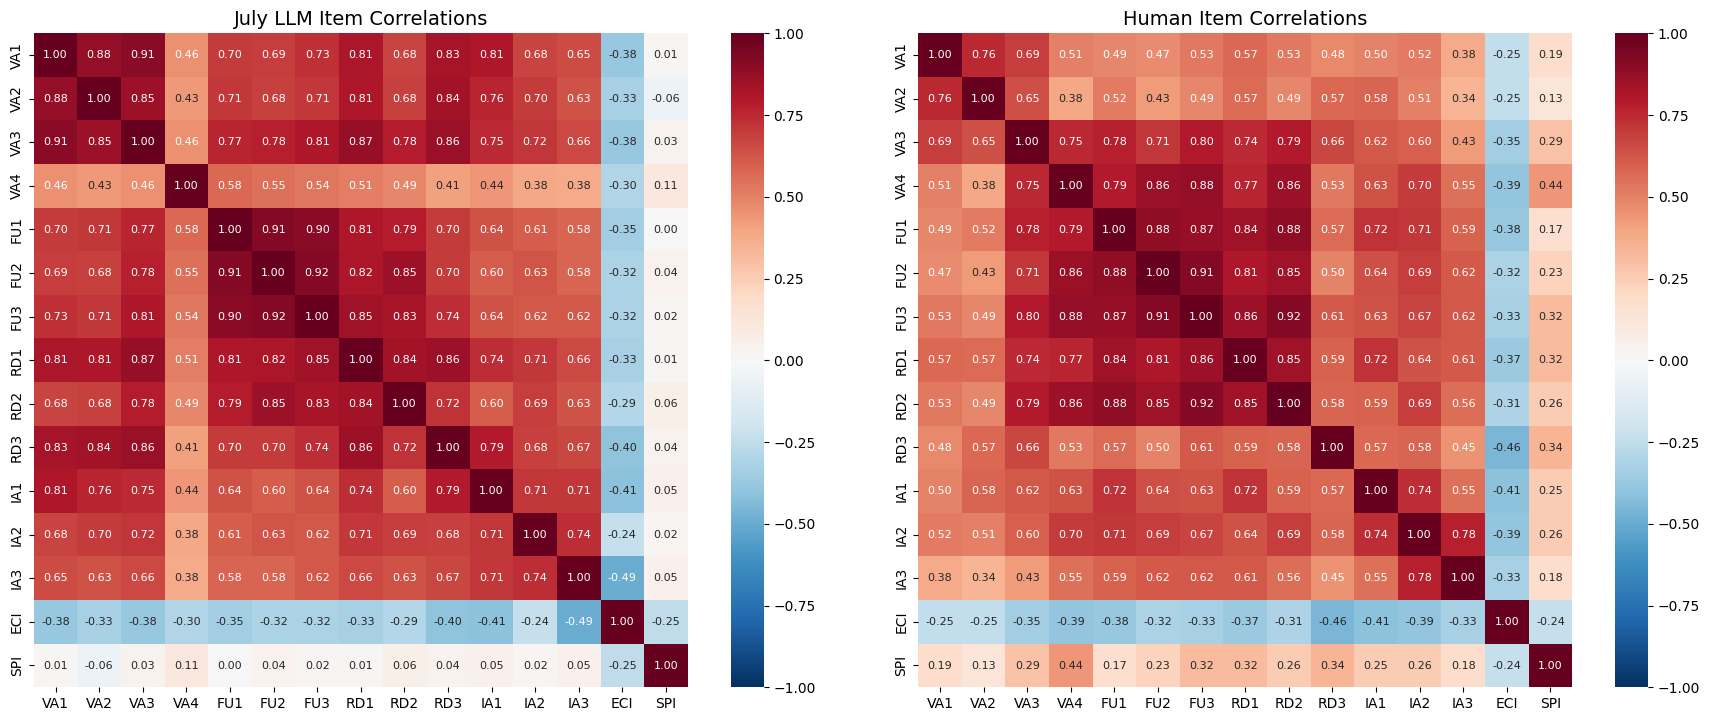

In [71]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

# Load the panel data
panel = load_panel()

# Set up the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Calculate and plot July LLM item correlations
july_corr = panel.july_ok[ALL_ITEMS].corr()
sns.heatmap(july_corr, ax=axes[0], cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, square=True)
axes[0].set_title("July LLM Item Correlations", fontsize=14)

# Calculate and plot Human item correlations
human_corr = panel.human[ALL_ITEMS].corr()
sns.heatmap(human_corr, ax=axes[1], cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}, square=True)
axes[1].set_title("Human Item Correlations", fontsize=14)

plt.tight_layout()
plt.show()

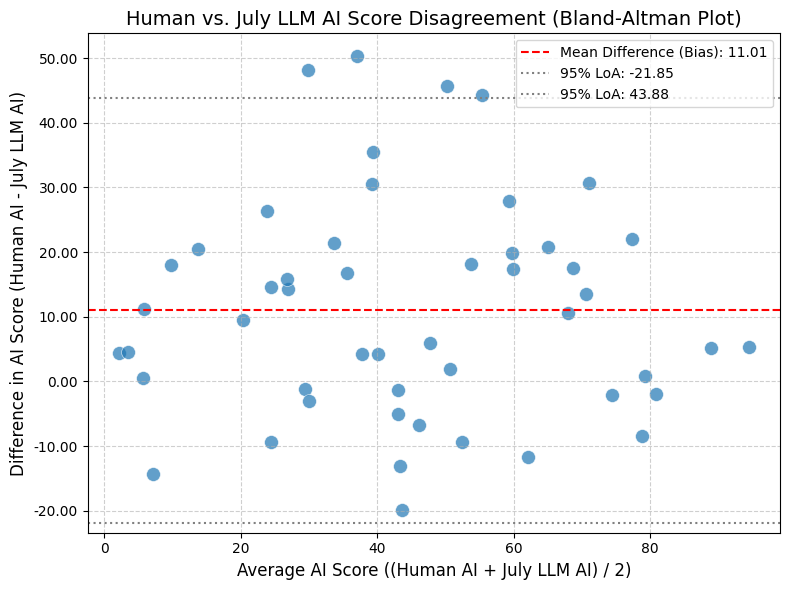

  📊 saved /content/psychometrics/fig_human_llm_disagreement.png


In [73]:
from matplotlib.ticker import FormatStrFormatter

# Get the merged data from the bland_altman results for July LLM
bland_altman_data = results["bland_altman"]["July LLM"]["merged"]

# Convert the list of dictionaries to a DataFrame
bland_altman_data = pd.DataFrame(bland_altman_data)

# Calculate the difference and mean AI scores
bland_altman_data['difference'] = bland_altman_data['human'] - bland_altman_data['llm']
bland_altman_data['mean'] = (bland_altman_data['human'] + bland_altman_data['llm']) / 2

# Create the Bland-Altman plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x='mean',
    y='difference',
    data=bland_altman_data,
    ax=ax,
    s=100,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5
)

bias = bland_altman_data['difference'].mean()
sd = bland_altman_data['difference'].std()
loa_lower = bias - 1.96 * sd
loa_upper = bias + 1.96 * sd

ax.axhline(bias, color='red', linestyle='--', label=f'Mean Difference (Bias): {bias:.2f}')
ax.axhline(loa_lower, color='gray', linestyle=':', label=f'95% LoA: {loa_lower:.2f}')
ax.axhline(loa_upper, color='gray', linestyle=':', label=f'95% LoA: {loa_upper:.2f}')

ax.set_title('Human vs. July LLM AI Score Disagreement (Bland-Altman Plot)', fontsize=14)
ax.set_xlabel('Average AI Score ((Human AI + July LLM AI) / 2)', fontsize=12)
ax.set_ylabel('Difference in AI Score (Human AI - July LLM AI)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)

# Format y-axis ticks to two decimal places
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

# Save the figure
_savefig(fig, "fig_human_llm_disagreement.png")